In [1]:
import sys
from pathlib import Path


def sys_path_show():
    print(*sys.path, sep='\n')


def sys_path_append(p):
    p = Path(p)
    assert p.exists()
    p = str(p)
    None if p in sys.path else sys.path.append(p)


sys_path_append(Path("~/link").expanduser())
sys_path_append(Path("~/link/temp/241120_other_model/learn_TOSICA").expanduser())

In [2]:
import utils as ut
from utils.general import *
sc = ut.sc.sc

对于TOSICA本地化的修改

> 修改文件`TOSICA/__init__.py`

```python
# __version__ = '1.0.0'
# 就地导入，TOSICA并不存在于python3.9/site-packages
# version存放在上一级目录
from pathlib import Path
__version__ = Path(__file__).absolute().parent.parent.joinpath('VERSION.txt').read_text().replace('\n','')

```

> 修改文件 `TOSICA/train.py`

```python
def fit_model(adata, gmt_path, project = None,...):
    # ...

    # project_path = os.getcwd()+'/%s'%project
    # if os.path.exists(project_path) is False:
    #     os.makedirs(project_path)

    # 使用直接传入的路径
    from pathlib import Path
    project_path = Path(project).joinpath('TrainingModel')
    project_path.mkdir(parents=True,exist_ok=True)
    project = project_path.name
    project_path = str(project_path)

    # ...

```

> 修改文件 `TOSICA/pre.py`

```python

def prediect( #....
    # mask = np.load(mask_path)
    # project_path = os.getcwd()+'/%s'%project
    # pathway = pd.read_csv(project_path+'/pathway.csv', index_col=0)
    # dictionary = pd.read_table(project_path+'/label_dictionary.csv', sep=',',header=0,index_col=0)

    # 使用直接传入的路径 并读取 mask,pathway,dictionary
    from pathlib import Path
    project_path = Path(project)
    mask = np.load(project_path.joinpath('TrainingModel','mask.npy'))
    pathway = pd.read_csv(project_path.joinpath('TrainingModel','pathway.csv'), index_col=0)
    dictionary = pd.read_table(project_path.joinpath('TrainingModel',
                                                     'label_dictionary.csv'),
                               sep=',',header=0,index_col=0)
    project = project_path.name
    project_path = str(project_path)

```

In [3]:
from TOSICA import TOSICA

p_root_model = Path("~/link/temp/241120_other_model/learn_TOSICA").expanduser()

In [4]:
map_sp = {k: v for k, v in zip(
    'h,m,z,ma,c,x'.split(','),
    'human,mouse,zebrafish,macaque,chicken,xenopus'.split(',')
)}
map_sp_reverse = {v: k for k, v in map_sp.items()}

map_sp.update({k: v for k, v in zip(
    'hs,mm'.split(','),
    'human,mouse'.split(',')
)})

p_root = Path('~/link/csMAHN_publish').expanduser()
p_res = p_root.joinpath("res")
p_cache = p_root.joinpath("cache")


def get_gmt_path(sp,p = p_root_model.joinpath('TOSICA_gmt_path.csv')):
    p = Path(p)
    df_gens = pd.read_csv(p).query("sp == '{}'".format(str(sp))).reset_index(drop=True)
    assert df_gens.shape[0] == 1,"[Error] get {} item with sp = {}".format(df_gens.shape[0],sp)
    return p.parent.joinpath(df_gens.at[0,'path'])

def get_TOSICA_weight_path(p):
    df_info = ut.df.iter_dir(p, path_match='model*pth')
    df_info['epoch'] = df_info['name'].str.extract("model-(\\d+)\\.pth", expand=False).astype(float)
    df_info = df_info.sort_values('epoch', ascending=False).reset_index(drop=True)
    print('[msg] get max epoch {}'.format(df_info.at[0, 'epoch']))
    return df_info.at[0, 'path']

# [from func.py]---------------------------------------------------------------------------

def get_path_varmap(
        sp_ref,
        sp_que,
        p_df_varmap=p_root.joinpath('homo/df_varmap.csv'),
        p_maps_SAMap=p_root.joinpath('homo/SAMap/maps_gene_name'),
        model='csMAHN'):
    """
    通过sp_ref 和 sp_que获取path_varmap
    ./homo/df_varmap.csv 存储了
    path_varmap路径及信息
"""
    p_df_varmap = Path(p_df_varmap)
    if model in 'TOSICA'.split(','):
        df_varmap = pd.read_csv(p_df_varmap)
        index_ = df_varmap.query(
            "sp_ref == '{}' & sp_que == '{}'".format(
                sp_ref, sp_que)).index
        assert index_.size == 1, "[get {} path]can not get speicifed and unique path\nsp_ref\tsp_que\n{}\t{}".format(
            index_.size, sp_ref, sp_que)
        res = Path(df_varmap.loc[index_[0], 'path'])
        if not res.is_absolute():
            res = p_df_varmap.parent.joinpath(res)
        assert res.exists(), "[not exists] {}".format(res)
        return res

    elif model == 'SAMap':
        return p_maps_SAMap
    else:
        raise Exception(
            "[Error] can not find path_varmap with model '{}'".format(model))


def get_1v1_matches(
        df_match,
        key_homology_type='homology_type',
        value_homology_type='ortholog_one2one'):
    """
    from came.pp.take_1v_matches
    """
    l, r = df_match.columns[:2]
    l_unique = df_match[l].value_counts(
    ).to_frame().query("count == 1").index
    r_unique = df_match[r].value_counts(
    ).to_frame().query("count == 1").index
    keep = pd.DataFrame({
        'l_is_unique': df_match[l].isin(l_unique),
        'r_is_unique': df_match[r].isin(r_unique)
    }).min(axis=1)
    df_match = df_match[keep]
    df_match = df_match.query(
        "{} == '{}'".format(
            key_homology_type,
            value_homology_type))
    return df_match


def df_varmap_query_exists(
        df_varmap,
        list_gn_ref=[],
        list_gn_que=[],
        model='both'):
    df_varmap = df_varmap.copy()
    df_varmap['gn_ref_exists'] = df_varmap['gn_ref'].isin(list_gn_ref)
    df_varmap['gn_que_exists'] = df_varmap['gn_que'].isin(list_gn_que)
    if model == 'both':
        df_varmap = df_varmap.query("gn_ref_exists & gn_que_exists")
    elif model == 'ref':
        df_varmap = df_varmap.query("gn_ref_exists")
    elif model == 'que':
        df_varmap = df_varmap.query("gn_que_exists")
    else:
        raise Exception('[Error] model must be one of both, ref, que')
    df_varmap = df_varmap.drop(
        columns='gn_ref_exists,gn_que_exists'.split(','))
    return df_varmap

def get_type_counts_info(adatas, key_class, dsnames):
    type_counts_list = []
    for i in range(len(adatas)):
        type_counts_list.append(pd.value_counts(adatas[i].obs[key_class]))
    counts_info = pd.concat(type_counts_list, axis=1, keys=dsnames)
    return counts_info

def aligned_type(adatas, key_calss):
    adata1 = adatas[0].copy()
    adata2 = adatas[1].copy()
    counts_info = get_type_counts_info(
        adatas, key_calss, dsnames=["reference", "query"]
    )
    print("----raw----")
    print(counts_info)
    counts_info = counts_info.dropna(how="any")
    print("----new----")
    print(counts_info)

    com_type = counts_info.index.tolist()
    adata1 = adata1[adata1.obs[key_calss].isin(com_type)]
    adata2 = adata2[adata2.obs[key_calss].isin(com_type)]
    return adata1, adata2

# df_homo = pd.read_csv(get_path_varmap(row['sp_ref'], row['sp_que'], model='TOSICA'),
#                       names='gn_ref,gn_que,type'.split(','), skiprows=1).dropna(axis=0)
# df_homo = get_1v1_matches(df_homo, 'type')
# df_homo = df_varmap_query_exists(df_homo, adata_ref.var.index,
#                                  adata_que.var.index, model='both')

# print('[msg] get {} one2one item'.format(df_homo.shape[0]))

# adata_ref = adata_ref[:, df_homo['gn_ref']].copy()
# adata_que = adata_que[:, df_homo['gn_que']].copy()
# adata_que.var.index = df_homo['gn_ref'].to_numpy()

In [5]:
# pd.DataFrame({
#     'sp':'h,m'.split(','),
#     'path':'TOSICA/TOSICA/GO_bp.gmt,TOSICA/TOSICA/m_GO_bp.gmt'.split(',')
# }).to_csv('TOSICA_gmt_path.csv',index=False)


In [6]:
# [run TOSICA]---------------------------------------------------------------------------

def precess_after_TOSICA(
    resdir, tissue_name, sp1, sp2, is_display=False, **kvargs
):
    adata = kvargs.setdefault('adt',None)
    assert not adata is None
    adata.obs['true_label'] = adata.obs['cell_type']
    adata.obs['is_right'] = adata.obs.eval('true_label == pre_label')
    sc.pp.neighbors(adata, use_rep='X')
    sc.tl.umap(adata)
    adata.obs = adata.obs.join(pd.DataFrame(adata.obsm['X_umap'],index=adata.obs.index,columns='UMAP1,UMAP2'.split(',')))\
        .loc[:,'UMAP1,UMAP2,dataset,cell_type,true_label,pre_label,max_prob,is_right'.split(',')]
    adata.obs.to_csv(resdir.joinpath('obs.csv'),index=True)
    # plot
    resdir.joinpath('figs').mkdir(exist_ok=True,parents=True)
    sc.pl.umap(adata,color='cell_type',size=2,return_fig=True)\
        .savefig(resdir.joinpath('figs/umap_umap.png'))
    sc.pl.umap(adata,color='dataset',size=2,return_fig=True)\
        .savefig(resdir.joinpath('figs/umap_dataset.png'))

def run_TOSICA(
    path_adata1,
    path_adata2,
    key_class1,
    key_class2,
    sp1,
    sp2,
    tissue_name,
    path_varmap,
    limite_func=lambda adata1,adata2: (adata1,adata2),
    aligned=False,
    resdir_tag=".",
    resdir=Path('.'), **kvargs
):
    """
    version:0.0.5
    kvargs:
        n_epochs: int
            default,50 见TACTiCS tutorial
    """

    # Parameter settings
    n_epochs = sum(kvargs.setdefault("n_epochs", [50]))

    # setting directory for results
    if len(resdir_tag) > 0:

        resdir_tag = "{}_{}-corss-{};{}".format(
            tissue_name, sp1, sp2, resdir_tag)
    else:
        resdir_tag = "{}_{}-corss-{}".format(tissue_name, sp1, sp2)

    resdir = resdir.joinpath(resdir_tag)

    # 终止 判断
    p_finish = resdir.joinpath("finish")
    if p_finish.exists():
        # precess_after_came(resdir,tissue_name,sp1, sp2)
        print(
            "[has finish]{} {}".format(
                time.strftime('%y%m%d-%H%M', time.localtime()),
                resdir.name)
        )
        return
    print(
        "[start]{} {}".format(
            time.strftime('%y%m%d-%H%M', time.localtime()),
            resdir.name

        ))
    # return

    figdir = resdir.joinpath("figs")
    sc.settings.figdir = figdir
    resdir.mkdir(parents=True, exist_ok=True)

    finish_content = ["[strat] {}".format(time.time())]

    # # setting
    dsnames = (
        '{}_{}'.format(
            tissue_name, sp1), '{}_{}'.format(
            tissue_name, sp2))
    dsn1, dsn2 = dsnames

    # load data
    adata_raw1 = ut.sc.load_adata(path_adata1)
    adata_raw2 = ut.sc.load_adata(path_adata2)

    df_homo = pd.read_csv(path_varmap,names='gn_ref,gn_que,type'.split(','),
                          skiprows=1).dropna(axis=0)
    df_homo = get_1v1_matches(df_homo, 'type')
    df_homo = df_varmap_query_exists(df_homo, adata_raw1.var.index,
                                     adata_raw2.var.index, model='both')
    print('[msg] get {} one2one item'.format(df_homo.shape[0]))
    
    # the var_names (genes) of the ref_adata and query_adata 
    # must be consistent and in the same order.
    # 即 one2one
    adata_raw1 = adata_raw1[:, df_homo['gn_ref']].copy()
    adata_raw2 = adata_raw2[:, df_homo['gn_que']].copy()
    adata_raw2.var.index = df_homo['gn_ref'].to_numpy()
    
    key_class = key_class1
    if key_class not in adata_raw2.obs.columns:
        adata_raw2.obs[key_class] = ''
    
    # limite 进一步对adata进行限制，默认不操作直接返回
    adata_raw1, adata_raw2 = limite_func(adata_raw1, adata_raw2)

    # group_counts_unalign.csv
    pd.concat(
        [
            adata_raw1.obs[key_class1].value_counts(),
            adata_raw2.obs[key_class2].value_counts(),
        ],
        axis=1,
        keys=dsnames,
    ).to_csv(resdir.joinpath("group_counts_unalign.csv"), index=True)
    # align
    if aligned:
        adata_raw1, adata_raw2 = aligned_type(
            [adata_raw1, adata_raw2], key_calss=key_class1
        )

    # 保存obs ,即真正测试的细胞的mata
    adata_raw1.obs.to_csv(resdir.joinpath("obs_ref.csv"), index=True)
    adata_raw2.obs.to_csv(resdir.joinpath("obs_que.csv"), index=True)


    # group_counts.csv
    temp = pd.concat(
        [
            adata_raw1.obs[key_class1].value_counts(),
            adata_raw2.obs[key_class2].value_counts(),
        ],
        axis=1,
        keys=dsnames,
    )
    temp.to_csv(resdir.joinpath("group_counts.csv"), index=True)
    if temp.shape[0] < 2:
        # 错误标记
        print("[Error][group_counts no any item]")
        finish_content.append(
            "[Error][group_counts no any item] %f" % time.time()
        )
        p_finish.with_name("error").write_text("\n".join(finish_content))
        return

    print("cell count --> {}".format(sum([adata_raw1.shape[0]+adata_raw2.shape[0]])))
    
    kvargs.update({'path_adata1': str(path_adata1),
                   'path_adata2': str(path_adata2),
                   'key_class1': key_class1,
                   'key_class2': key_class2,
                   'sp1': sp1,
                   'sp2': sp2,
                   'tissue_name': tissue_name,
                   'path_varmap': str(path_varmap),
                   'aligned': aligned,
                   'resdir_tag': resdir_tag,
                   'resdir': str(resdir),
                   'n_epochs':n_epochs}
                  )
    
    resdir.joinpath("kvargs.json").write_text(json.dumps(kvargs))

    finish_content.append("[finish before run] {}".format(time.time()))


    # TOSICA Step 1: Training the model
    if Path(resdir).joinpath('TrainingModel','model-9.pth').exists():
        print("[msg][has finish] TOSICA TrainingModel")
    else:
        print("\n[start ] TOSICA TrainingModel\n".center(100,'-'))
        
        TOSICA.train(adata_raw1,str(get_gmt_path(sp1)),
                     resdir,label_name=key_class1)
        
        print("\n[finish] TOSICA TrainingModel\n".center(100,'-'))

     # TOSICA Step 2: Prediect by the model
    p_weight = get_TOSICA_weight_path(resdir.joinpath('TrainingModel'))
    adt = {}
    for k, adata_item in zip('ref,que'.split(','), [adata_raw1, adata_raw2]):
        print("[TOSICA.pre] {}".format(k).ljust(75,'-'))
        adt[k] = TOSICA.pre(adata_item,model_weight_path=p_weight,project=resdir)
        adt[k].obs = adt[k].obs.loc[:, 'Prediction,Probability'.split(',')]
        if resdir.joinpath('gene2token_weights.csv').exists():
            resdir.joinpath('gene2token_weights.csv').rename(
                resdir.joinpath('gene2token_weights.csv')
                .with_name('gene2token_weights_{}.csv'.format(k)))
            print('[msg] [rename] {0}.csv -> {0}_{1}.csv'.format('gene2token_weights',k))
    adt = sc.concat(adt)
    adt.obs = adt.obs.rename(columns={
        'Prediction':'pre_label',
        'Probability':'max_prob'
    })
    adt.obs = adt.obs.join(pd.concat([
        adata_raw1.obs.loc[:,[key_class1]]\
            .rename(columns={key_class1:'cell_type'})\
            .assign(dataset = dsn1)
        ,
        adata_raw2.obs.loc[:,[key_class2]]\
            .rename(columns={key_class2:'cell_type'})\
            .assign(dataset = dsn2)
            ],axis=0))
    
    adt.write_h5ad(resdir.joinpath('adt.h5ad'))
    finish_content.append("[finish run] {}".format(time.time()))
    
    # 后处理
    precess_after_TOSICA(resdir, tissue_name, sp1, sp2,
                         is_display=False, adt = adt)
    finish_content.append("[finish after run] {}".format(time.time()))

    # 完成标记
    finish_content.append("[end] {}".format(time.time()))
    p_finish.write_text("\n".join(finish_content))

map_func_run_cross_species_models = {
    'TOSICA': run_TOSICA,

}

del run_TOSICA
def run_cross_species_models(
    path_adata1,
    path_adata2,
    key_class1,
    key_class2,
    sp1,
    sp2,
    tissue_name,
    resdir,
    resdir_tag="",
    aligned=False,
    limite_func=lambda adata1, adata2: (adata1, adata2),
    models=''.split(','),
    **kvargs
):
    """
        models: TOSICA
        kvargs:
        n_epochs:
            default,None
        is_1v1: bool
            default,True TOSICA仅one2one
    """
    
    for model in models:
        path_varmap = get_path_varmap(map_sp[sp1], map_sp[sp2], model=model)
        print('[path_varmap] {}\t{}'.format(model, Path(path_varmap).name))
        map_func_run_cross_species_models[model](
            path_adata1,
            path_adata2,
            key_class1,
            key_class2,
            sp1,
            sp2,
            tissue_name,
            path_varmap,
            aligned=aligned,
            resdir_tag=";".join([model, resdir_tag]),
            resdir=resdir,
            limite_func=limite_func,
            **kvargs,
        )

[path_varmap] TOSICA	human_to_mouse.txt
[start]241125-2212 LC_h-corss-m;TOSICA;LChDCs-map-LCmDCs;is_1v1=True
[msg] get 14859 one2one item
----raw----
               reference  query
sub_cell_type                  
MonoDC              1097     76
DC2                  330    106
pDC                  311     52
DC1                  171    119
DC3                  101    293
----new----
               reference  query
sub_cell_type                  
MonoDC              1097     76
DC2                  330    106
pDC                  311     52
DC1                  171    119
DC3                  101    293
cell count --> 2656
[msg][has finish] TOSICA TrainingModel
[msg] get max epoch 9.0
[TOSICA.pre] ref-----------------------------------------------------------
cpu


/tmp/ipykernel_99504/3950205676.py:111: FutureWarning: pandas.value_counts is deprecated and will be removed in a future version. Use pd.Series(obj).value_counts() instead.
  type_counts_list.append(pd.value_counts(adatas[i].obs[key_class]))
/tmp/ipykernel_99504/3950205676.py:111: FutureWarning: pandas.value_counts is deprecated and will be removed in a future version. Use pd.Series(obj).value_counts() instead.
  type_counts_list.append(pd.value_counts(adatas[i].obs[key_class]))


0
2010


/public/workspace/licanchengup/apps/miniconda3/envs/TOSICA/lib/python3.9/site-packages/anndata/_core/anndata.py:1754: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")


[msg] [rename] gene2token_weights.csv -> gene2token_weights_ref.csv
[TOSICA.pre] que-----------------------------------------------------------
cpu
0
646


/public/workspace/licanchengup/apps/miniconda3/envs/TOSICA/lib/python3.9/site-packages/anndata/_core/anndata.py:1754: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")


[msg] [rename] gene2token_weights.csv -> gene2token_weights_que.csv
------------------------------------------
[finish][run]
-------------------------------------------


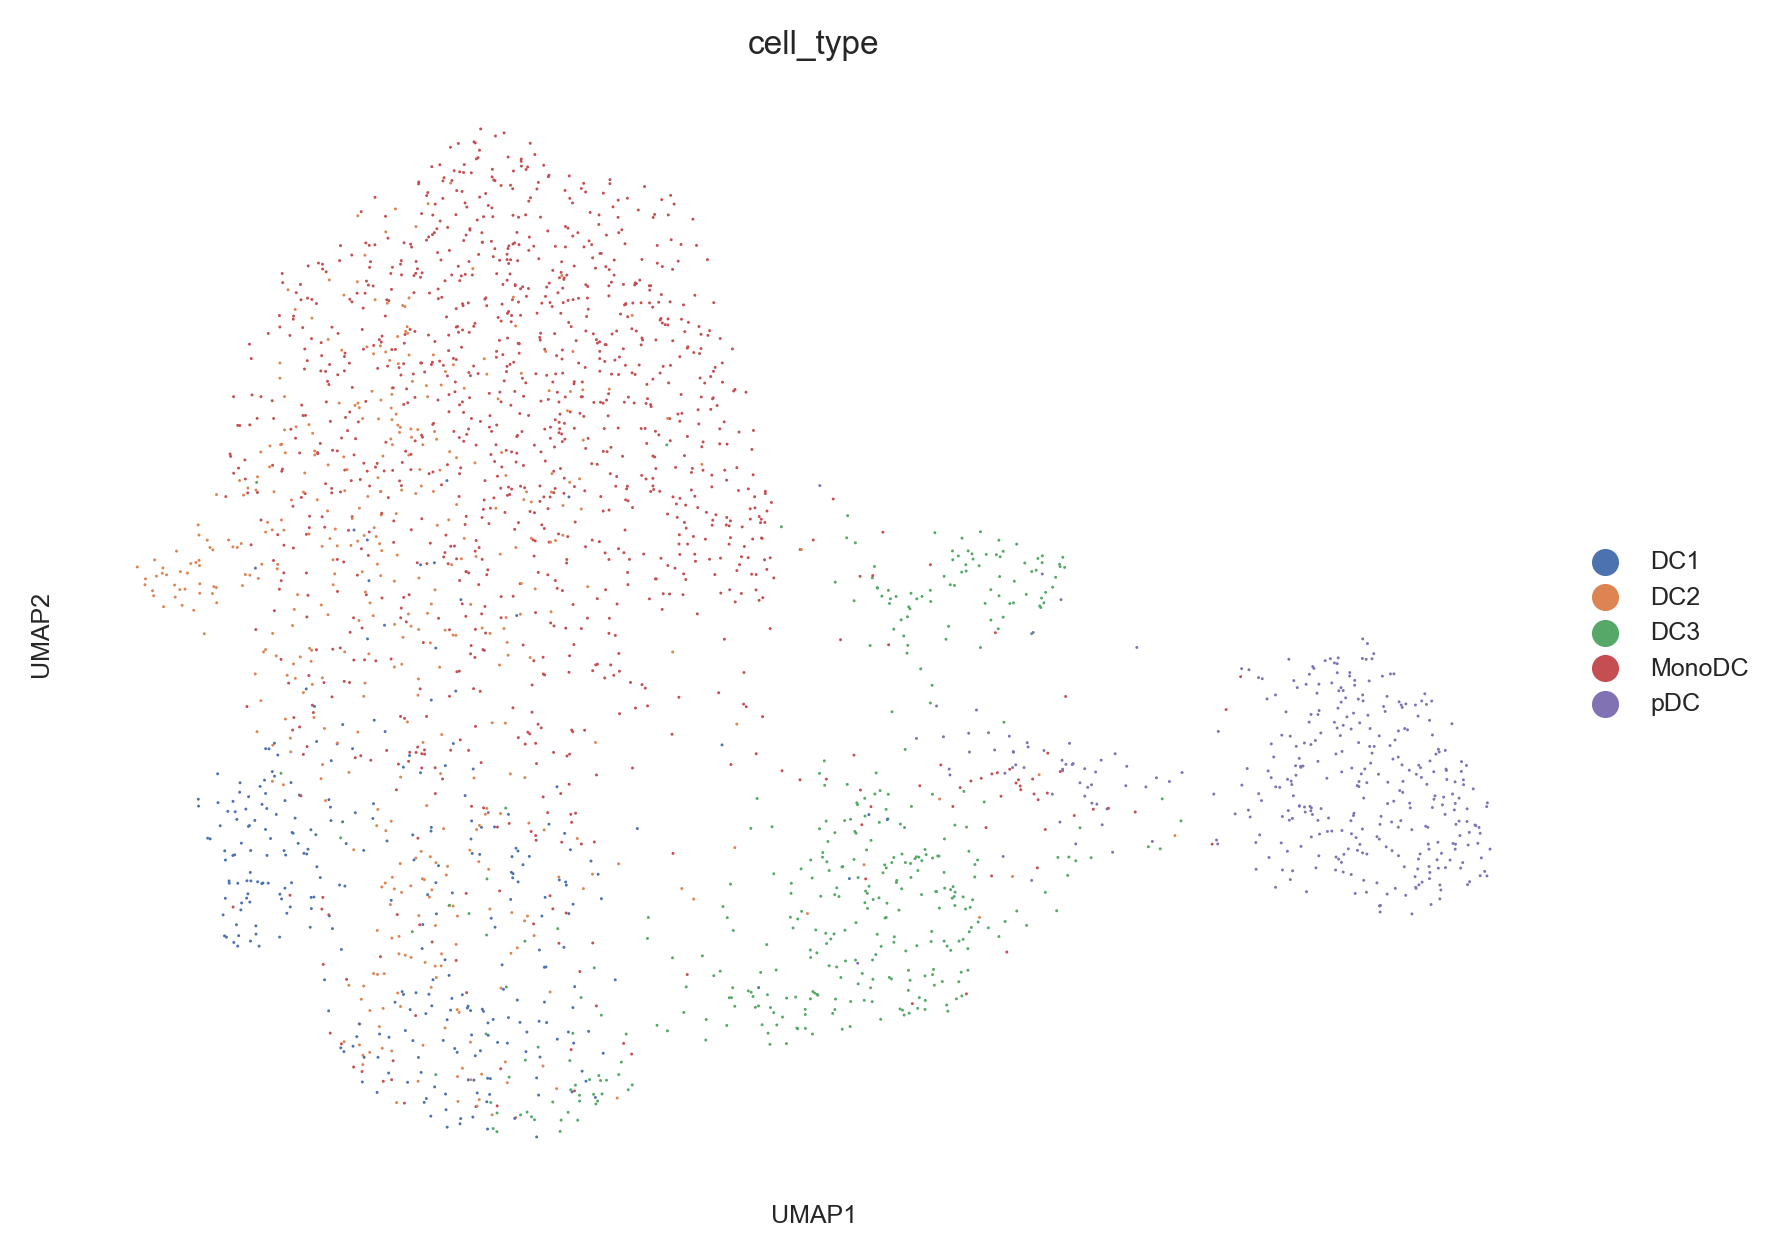

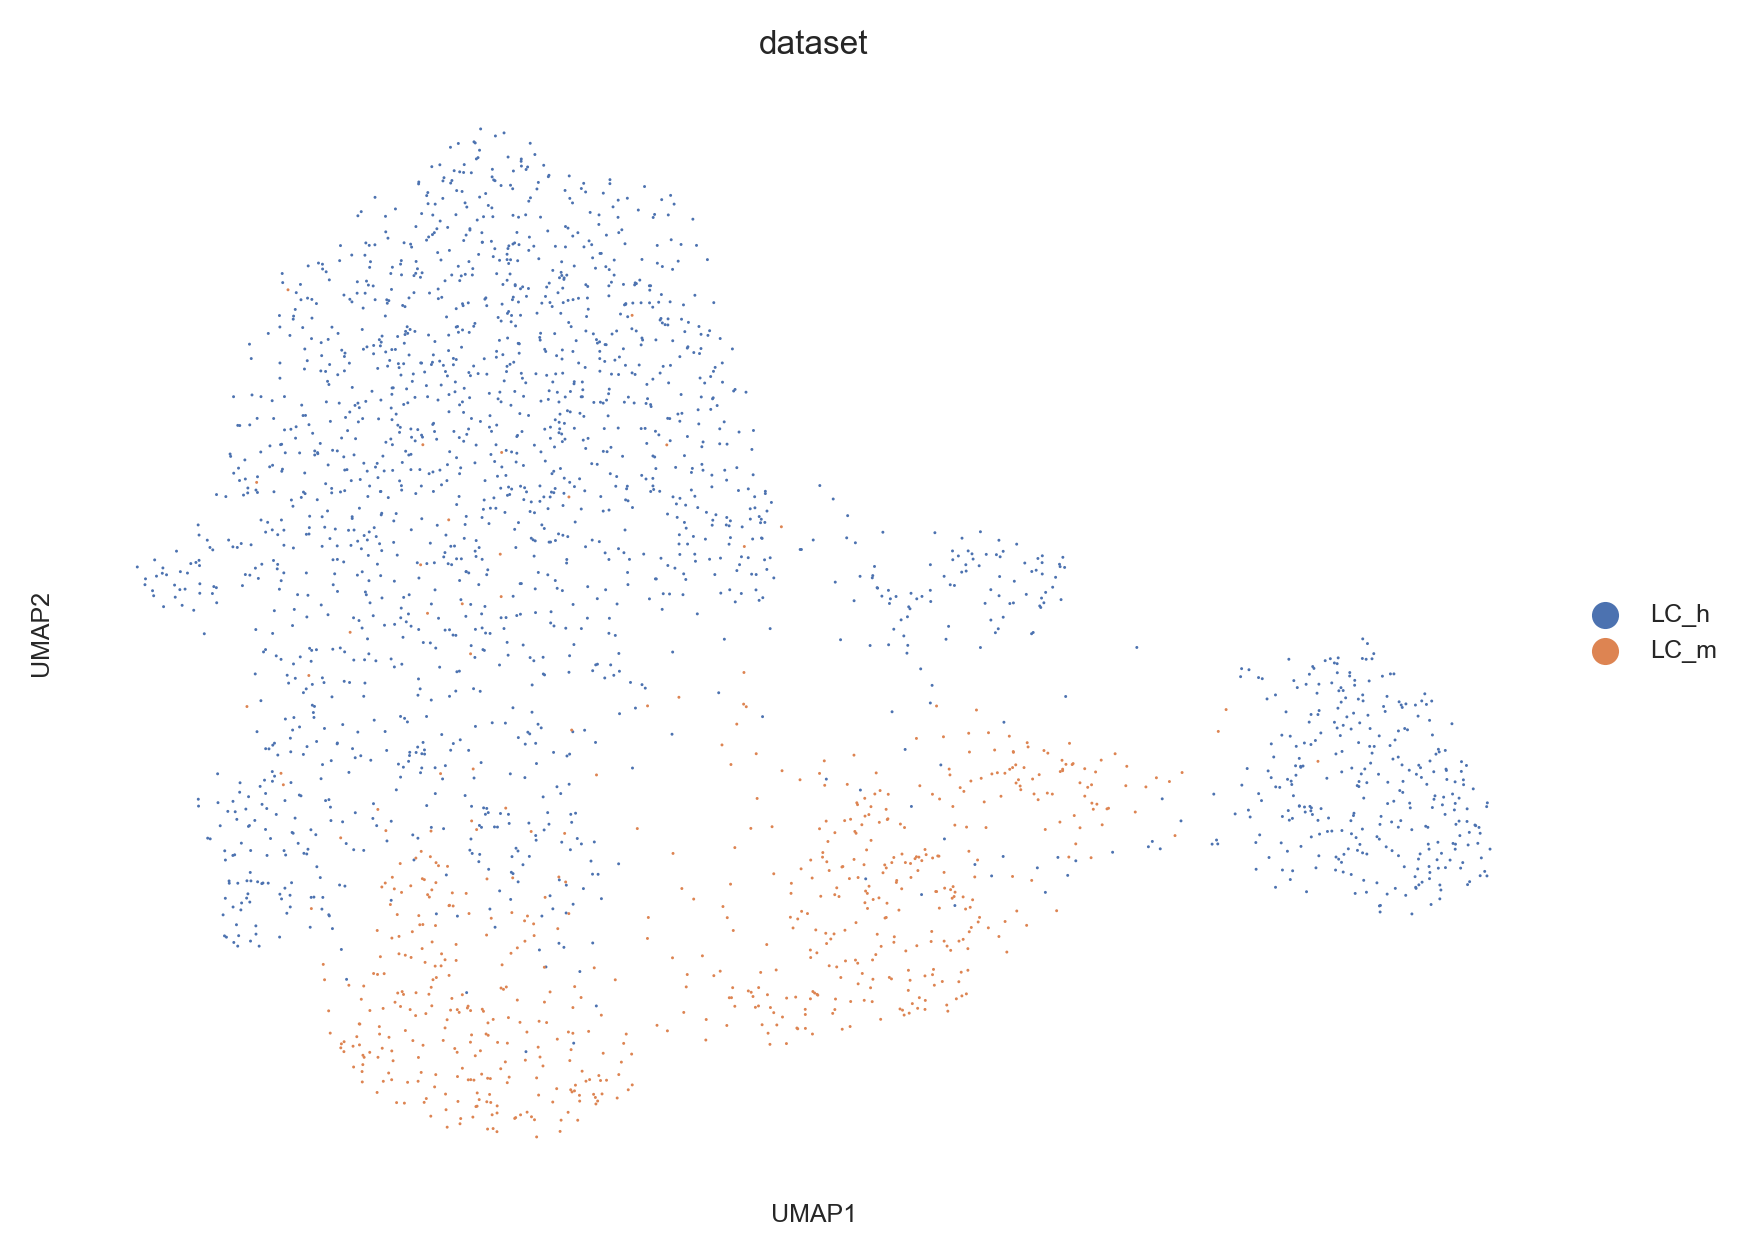

In [8]:
row = json.loads(Path('~/link/other_model').expanduser().joinpath("parameters_run_cross_species_models.json").read_text())
row
n_epochs = [0]
run_cross_species_models(
        path_adata1=row['path_ref'],
        path_adata2=row['path_que'],
        key_class1=row['key_cell_type'],
        key_class2=row['key_cell_type'],
        sp1=row['sp_simple_ref'],
        sp2=row['sp_simple_que'],
        tissue_name=row['tissue'],
        resdir_tag="{name_ref}-map-{name_que};is_1v1=True".format(**row),
        resdir=p_root_model,
        n_epochs=n_epochs,
        aligned=True,
        models = ['TOSICA'])
print("\n[finish][run]\n".center(100,'-'))

In [9]:
print("\n[finish]\n".center(100,'-'))

---------------------------------------------
[finish]
---------------------------------------------
